# Phase 3 - Exploratory Data Analysis (EDA)

## Objective

The objective of this phase is to explore the dataset visually and statistically to understand the relationships between features and the target variable (**SalePrice**). This analysis helps identify important patterns, trends, correlations, and potential outliers that influence house prices.

### Tasks Performed

- Analyze feature distributions
- Study relationships between features and SalePrice
- Perform correlation analysis
- Explore numerical and categorical variables
- Detect outliers
- Identify important features
- Generate meaningful visualizations

### Expected Outcome

- Better understanding of the dataset
- Identify influential features
- Discover hidden patterns
- Prepare insights for model development

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df=pd.read_csv("/home/aximsoft/Documents/EOWA/Week_08/Notebooks/dataset/house_prices_cleaned.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
0,1,4.110874,0.869742,1.646667,9.042040,0.526589,3,0.869742,0.0,0.959135,...,2,2008,1.162283,0.959135,208500,5,3.500000,15.552676,4.127134,0
1,2,3.044522,0.869742,1.685370,9.169623,0.526589,3,0.869742,0.0,0.741276,...,5,2007,1.162283,0.959135,181500,31,2.263295,9.238188,0.000000,0
2,3,4.110874,0.869742,1.655196,9.328212,0.526589,0,0.869742,0.0,0.959135,...,9,2008,1.162283,0.959135,223500,7,3.500000,15.647882,3.761200,1
3,4,4.262680,0.869742,1.631370,9.164401,0.526589,0,0.869742,0.0,0.000000,...,2,2006,1.162283,0.000000,140000,91,2.000000,15.530382,5.472023,1
4,5,4.110874,0.869742,1.694266,9.565284,0.526589,0,0.869742,0.0,0.741276,...,12,2008,1.162283,0.959135,250000,8,3.500000,16.089311,4.442651,0


In [3]:
# Dataset Shape
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 1366
Columns : 81


In [4]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1366 entries, 0 to 1365
Data columns (total 81 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              1366 non-null   int64  
 1   MSSubClass      1366 non-null   float64
 2   MSZoning        1366 non-null   float64
 3   LotFrontage     1366 non-null   float64
 4   LotArea         1366 non-null   float64
 5   Street          1366 non-null   float64
 6   LotShape        1366 non-null   int64  
 7   LandContour     1366 non-null   float64
 8   Utilities       1366 non-null   float64
 9   LotConfig       1366 non-null   float64
 10  LandSlope       1366 non-null   float64
 11  Neighborhood    1366 non-null   int64  
 12  Condition1      1366 non-null   float64
 13  Condition2      1366 non-null   float64
 14  BldgType        1366 non-null   float64
 15  HouseStyle      1366 non-null   int64  
 16  OverallQual     1366 non-null   int64  
 17  OverallCond     1366 non-null   int64  
 18 

In [5]:
# Statistical Summary
df.describe()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,TotalBathrooms,TotalSF,TotalPorchArea,RemodeledHouse
count,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,...,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000,1366.000000
mean,734.890922,3.825884,0.860616,1.646009,9.082071,0.524276,1.984627,0.816728,0.000385,0.752528,...,6.303807,2007.813324,1.115916,0.889544,166469.756955,38.380673,2.129047,11.797752,2.632798,0.467057
std,422.983300,0.694019,0.110330,0.062002,0.508372,0.034836,1.397192,0.189378,0.014248,0.368973,...,2.688862,1.326373,0.206363,0.251415,54675.183980,29.955621,0.754385,3.188016,2.168490,0.499096
min,1.000000,3.044522,0.000000,1.408800,7.170888,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2006.000000,0.000000,0.000000,34900.000000,0.000000,1.000000,5.814131,0.000000,0.000000
25%,368.250000,3.044522,0.869742,1.631370,8.908323,0.526589,0.000000,0.869742,0.000000,0.741276,...,5.000000,2007.000000,1.162283,0.959135,128050.000000,9.000000,1.500000,9.094847,0.000000,0.000000
50%,741.500000,3.931826,0.869742,1.655196,9.131946,0.526589,3.000000,0.869742,0.000000,0.959135,...,6.000000,2008.000000,1.162283,0.959135,157700.000000,37.000000,2.000000,9.523297,3.218876,0.000000
75%,1100.750000,4.262680,0.869742,1.675938,9.326722,0.526589,3.000000,0.869742,0.000000,0.959135,...,8.000000,2009.000000,1.162283,0.959135,199900.000000,56.000000,2.500000,15.350221,4.369448,1.000000
max,1460.000000,5.252273,0.959135,1.909453,12.011644,0.526589,3.000000,0.869742,0.526589,0.959135,...,12.000000,2010.000000,1.162283,1.026672,315000.000000,136.000000,6.000000,17.593496,8.276999,1.000000


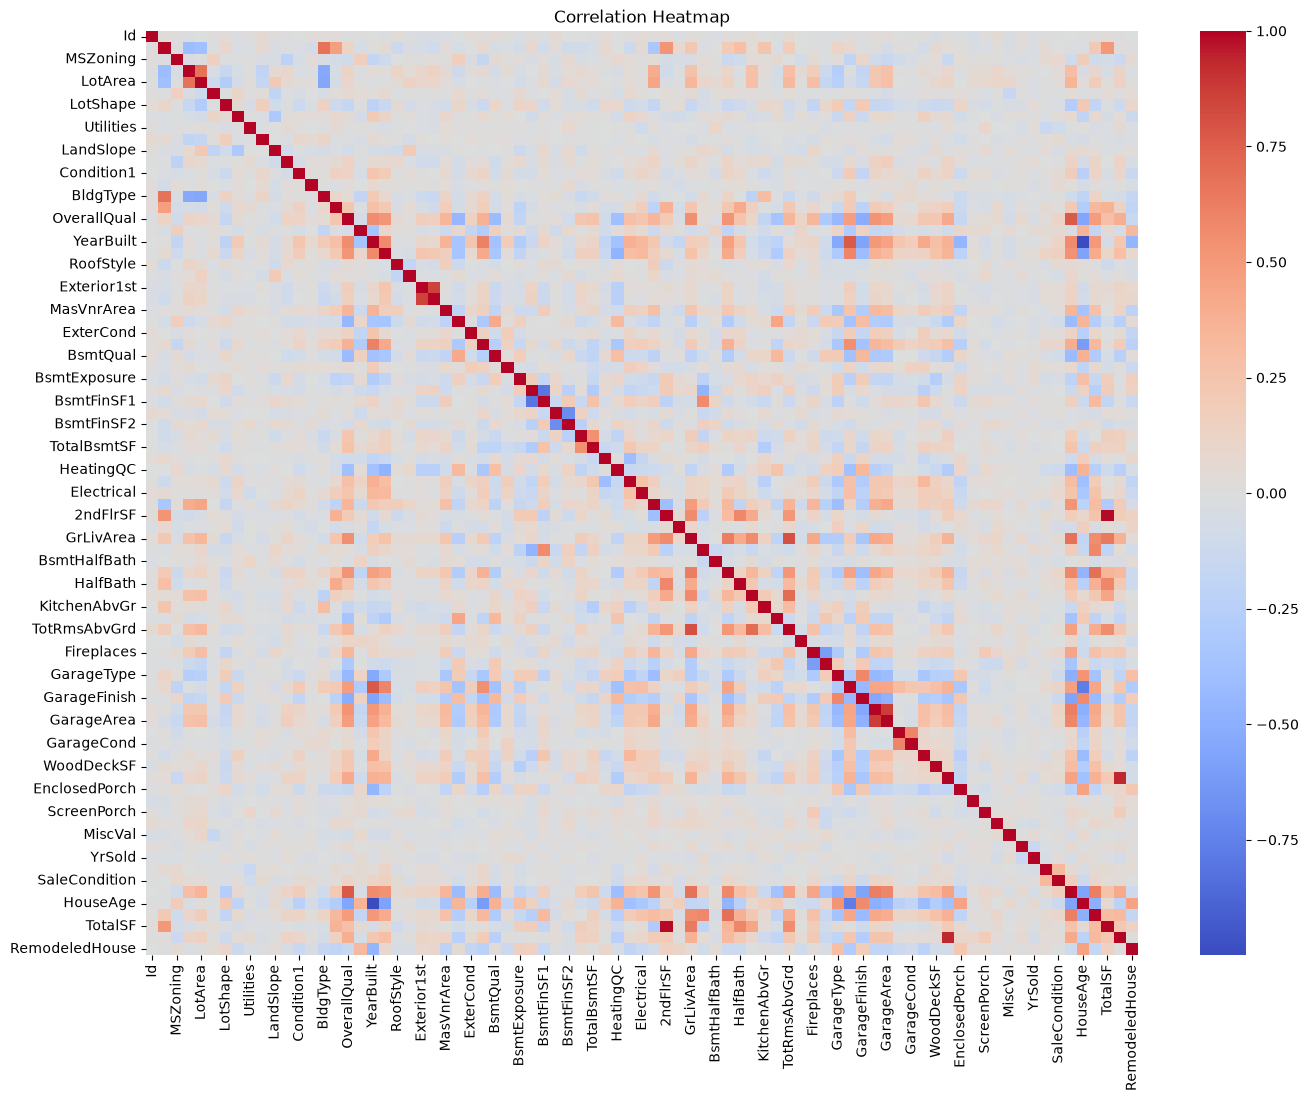

In [6]:
# Correlation Heatmap
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# Top Correlated Features with SalePrice
corr = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(20)

SalePrice         1.000000
OverallQual       0.769415
GrLivArea         0.679333
TotalBathrooms    0.624218
GarageCars        0.617408
GarageArea        0.587398
FullBath          0.579846
YearBuilt         0.565397
YearRemodAdd      0.535928
1stFlrSF          0.525171
GarageYrBlt       0.468422
TotRmsAbvGrd      0.465085
OpenPorchSF       0.455452
Fireplaces        0.443886
TotalPorchArea    0.417863
Foundation        0.394449
LotArea           0.352253
MasVnrArea        0.350672
CentralAir        0.306161
WoodDeckSF        0.301881
Name: SalePrice, dtype: float64

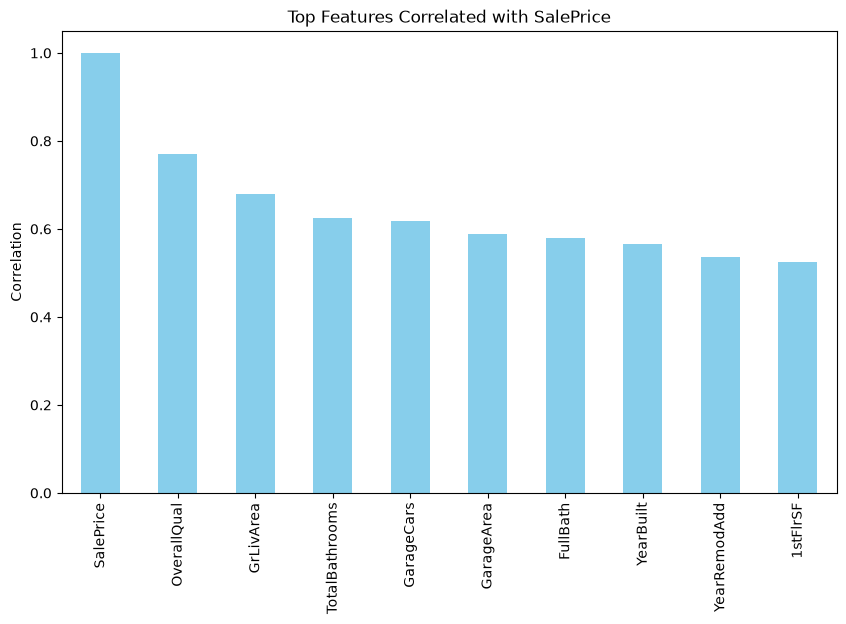

In [8]:
# Top 10 Features Correlation Bar Chart
plt.figure(figsize=(10,6))
corr.head(10).plot(kind="bar",color="skyblue")
plt.title("Top Features Correlated with SalePrice")
plt.ylabel("Correlation")
plt.show()

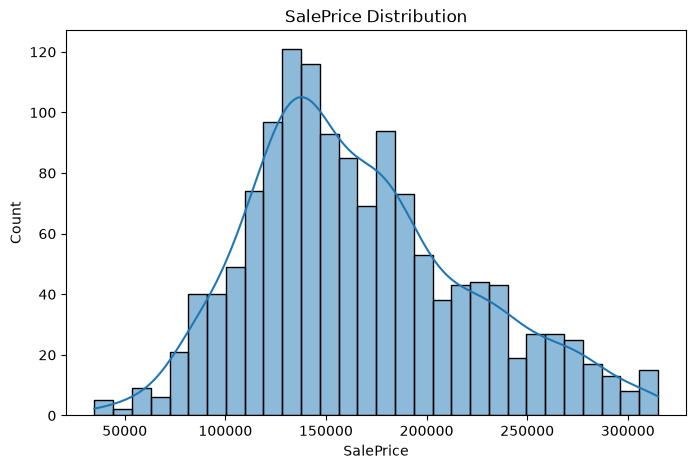

In [9]:
# SalePrice Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"],bins=30,kde=True)
plt.title("SalePrice Distribution")
plt.show()

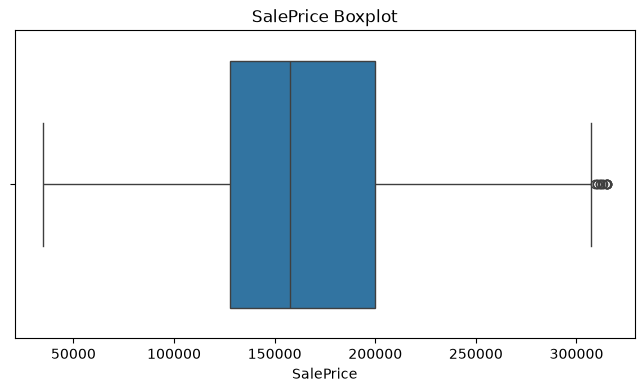

In [10]:
# SalePrice Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

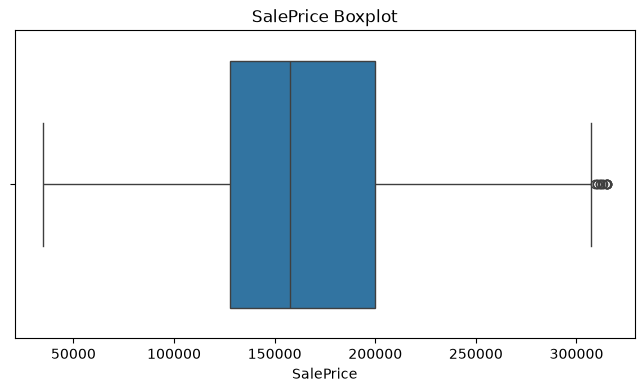

In [11]:
# SalePrice Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=df["SalePrice"])
plt.title("SalePrice Boxplot")
plt.show()

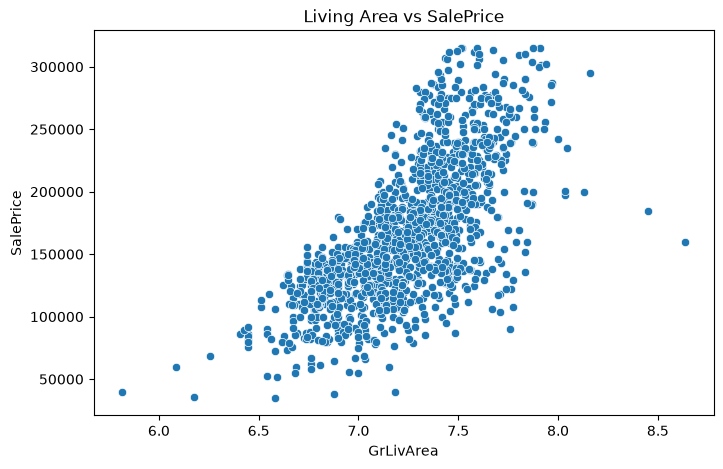

In [12]:
# Living Area vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="GrLivArea",y="SalePrice")
plt.title("Living Area vs SalePrice")
plt.show()

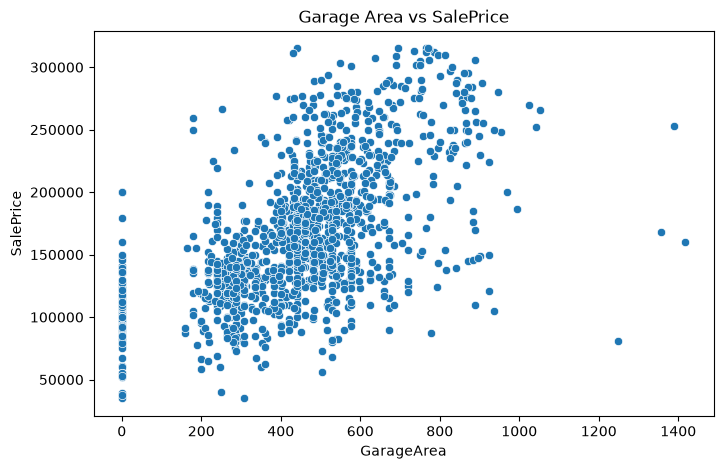

In [13]:
# Garage Area vs SalePrice
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="GarageArea",y="SalePrice")
plt.title("Garage Area vs SalePrice")
plt.show()

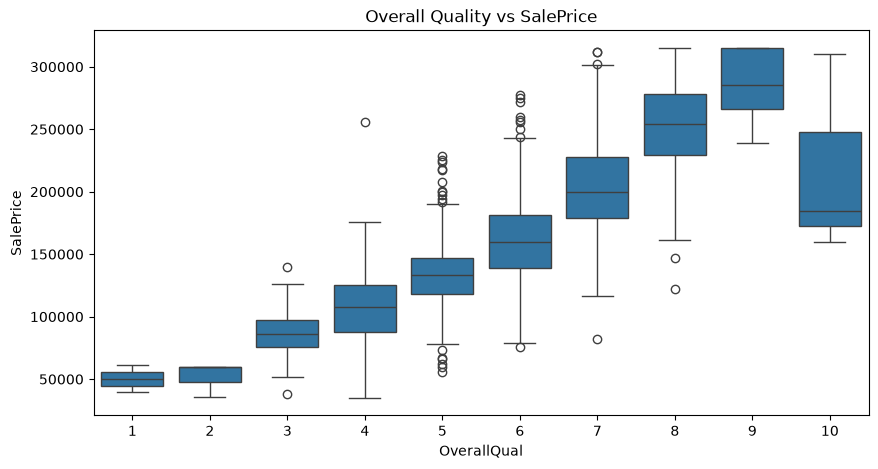

In [14]:
# Overall Quality vs SalePrice
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="OverallQual",y="SalePrice")
plt.title("Overall Quality vs SalePrice")
plt.show()

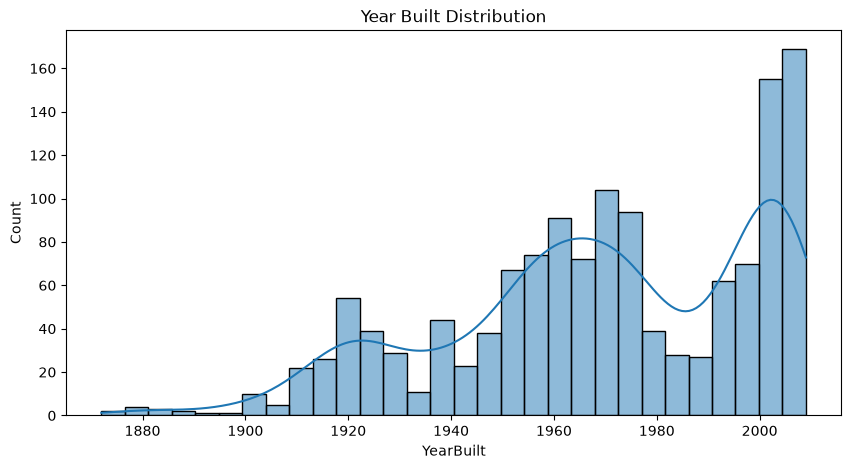

In [15]:
# Year Built Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["YearBuilt"],bins=30,kde=True)
plt.title("Year Built Distribution")
plt.show()

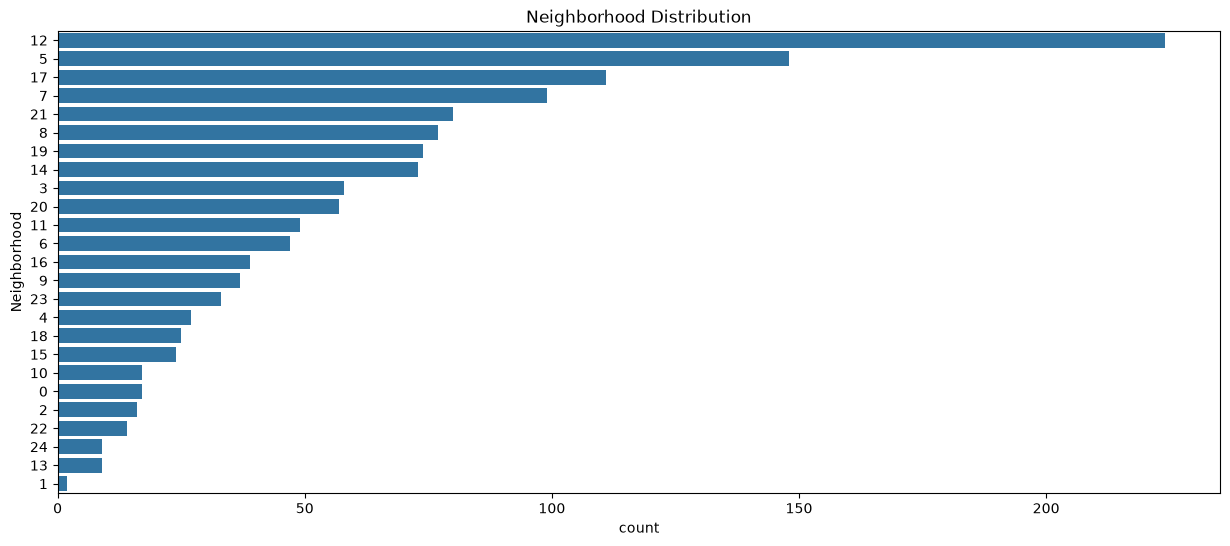

In [16]:
# Neighborhood Count
plt.figure(figsize=(15,6))
sns.countplot(data=df,y="Neighborhood",order=df["Neighborhood"].value_counts().index)
plt.title("Neighborhood Distribution")
plt.show()

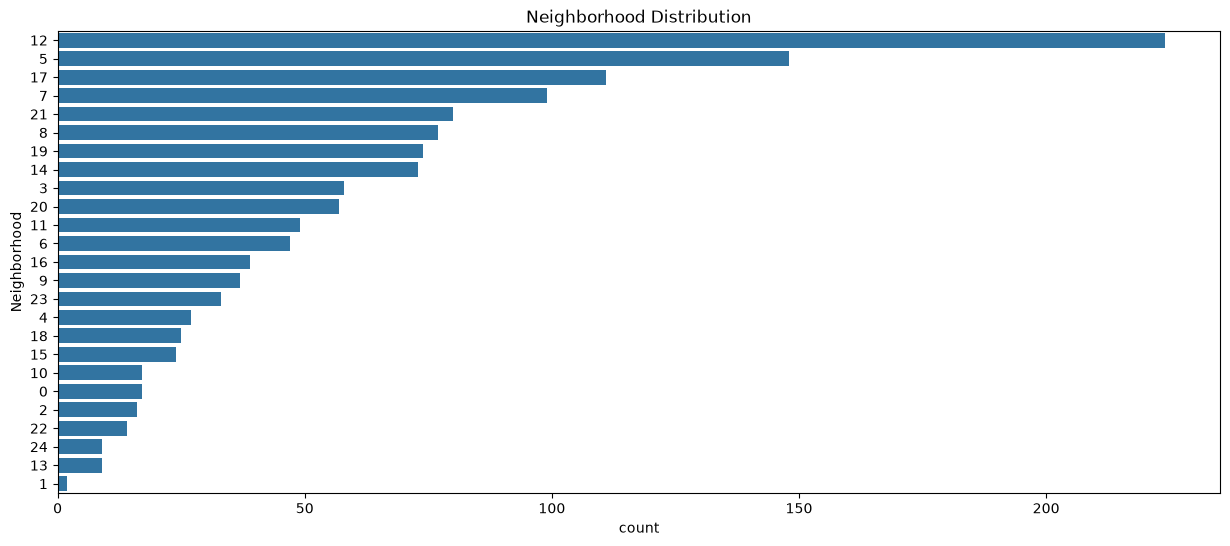

In [17]:
# Neighborhood Count
plt.figure(figsize=(15,6))
sns.countplot(data=df,y="Neighborhood",order=df["Neighborhood"].value_counts().index)
plt.title("Neighborhood Distribution")
plt.show()

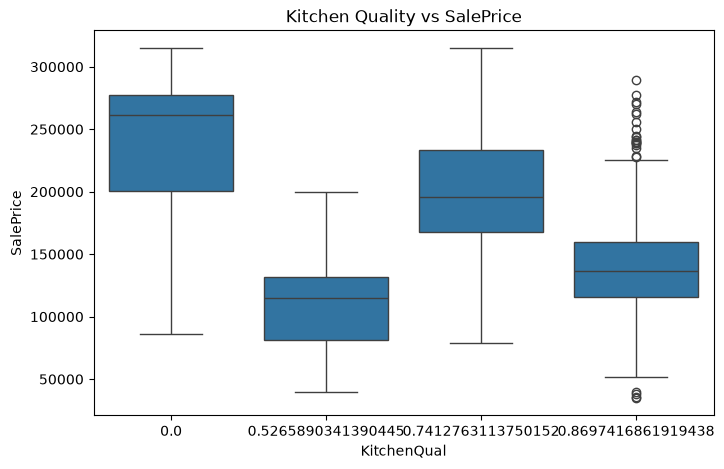

In [18]:
# Kitchen Quality vs SalePrice
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="KitchenQual",y="SalePrice")
plt.title("Kitchen Quality vs SalePrice")
plt.show()

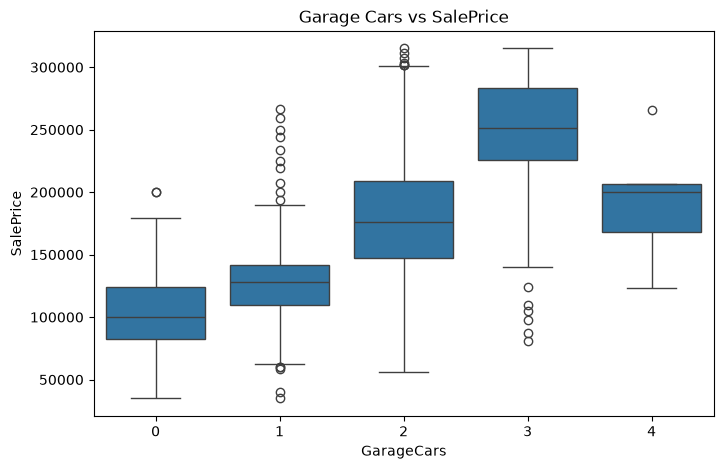

In [19]:
# Garage Cars vs SalePrice
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="GarageCars",y="SalePrice")
plt.title("Garage Cars vs SalePrice")
plt.show()

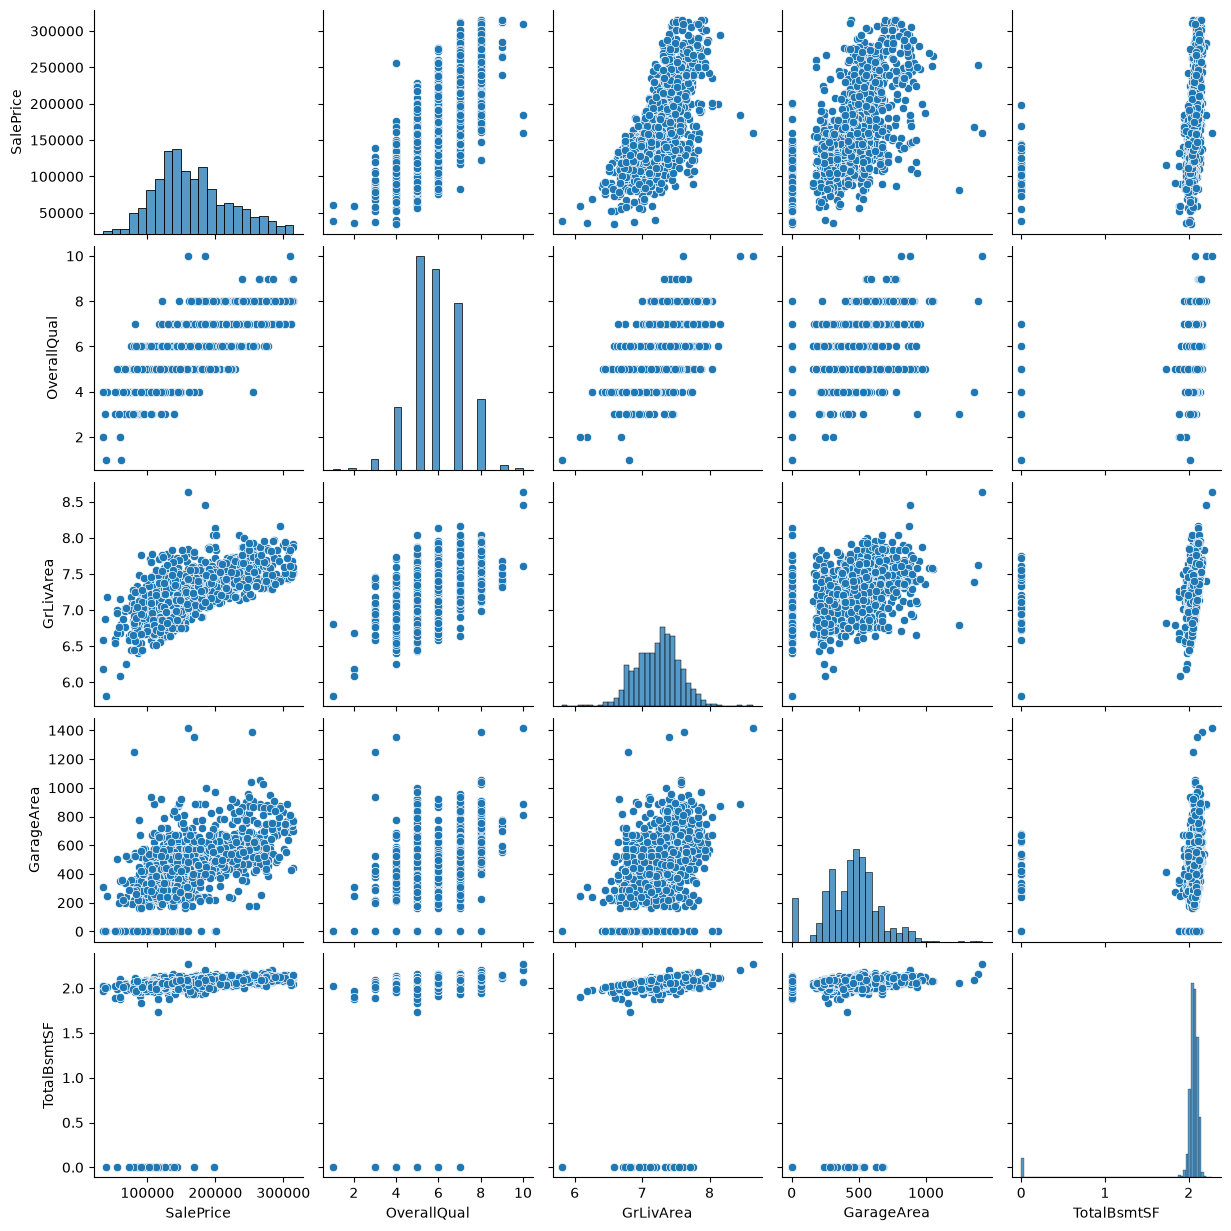

In [20]:
# Pair Plot
features=["SalePrice","OverallQual","GrLivArea","GarageArea","TotalBsmtSF"]
sns.pairplot(df[features])
plt.show()

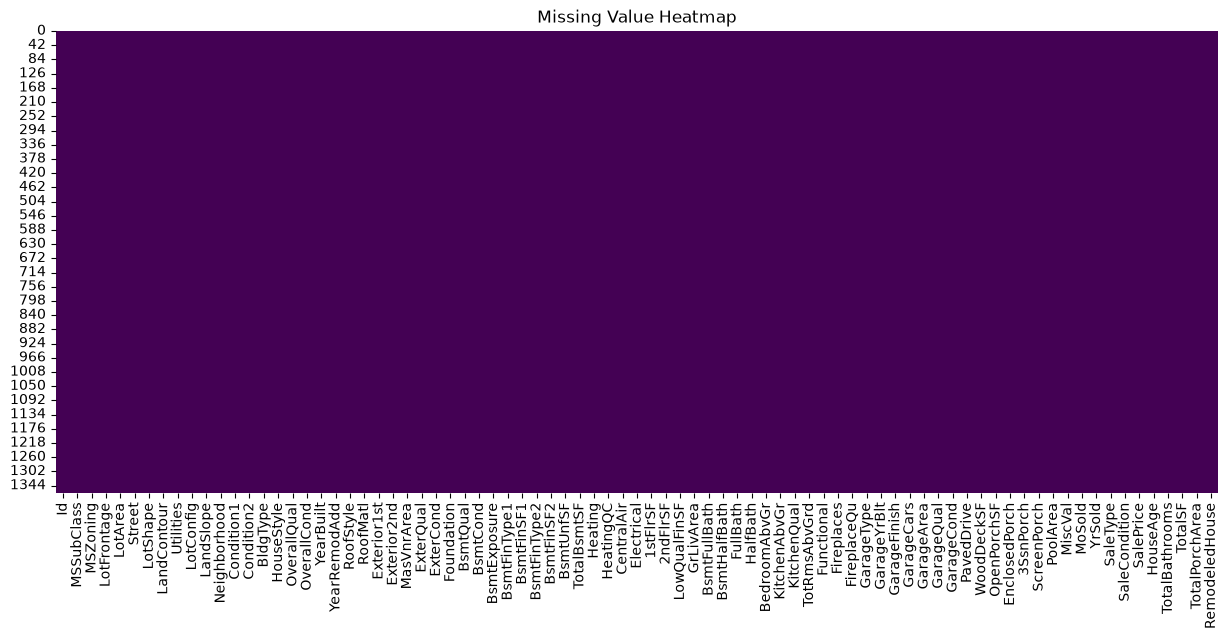

In [21]:
# Missing Value Heatmap
plt.figure(figsize=(15,6))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

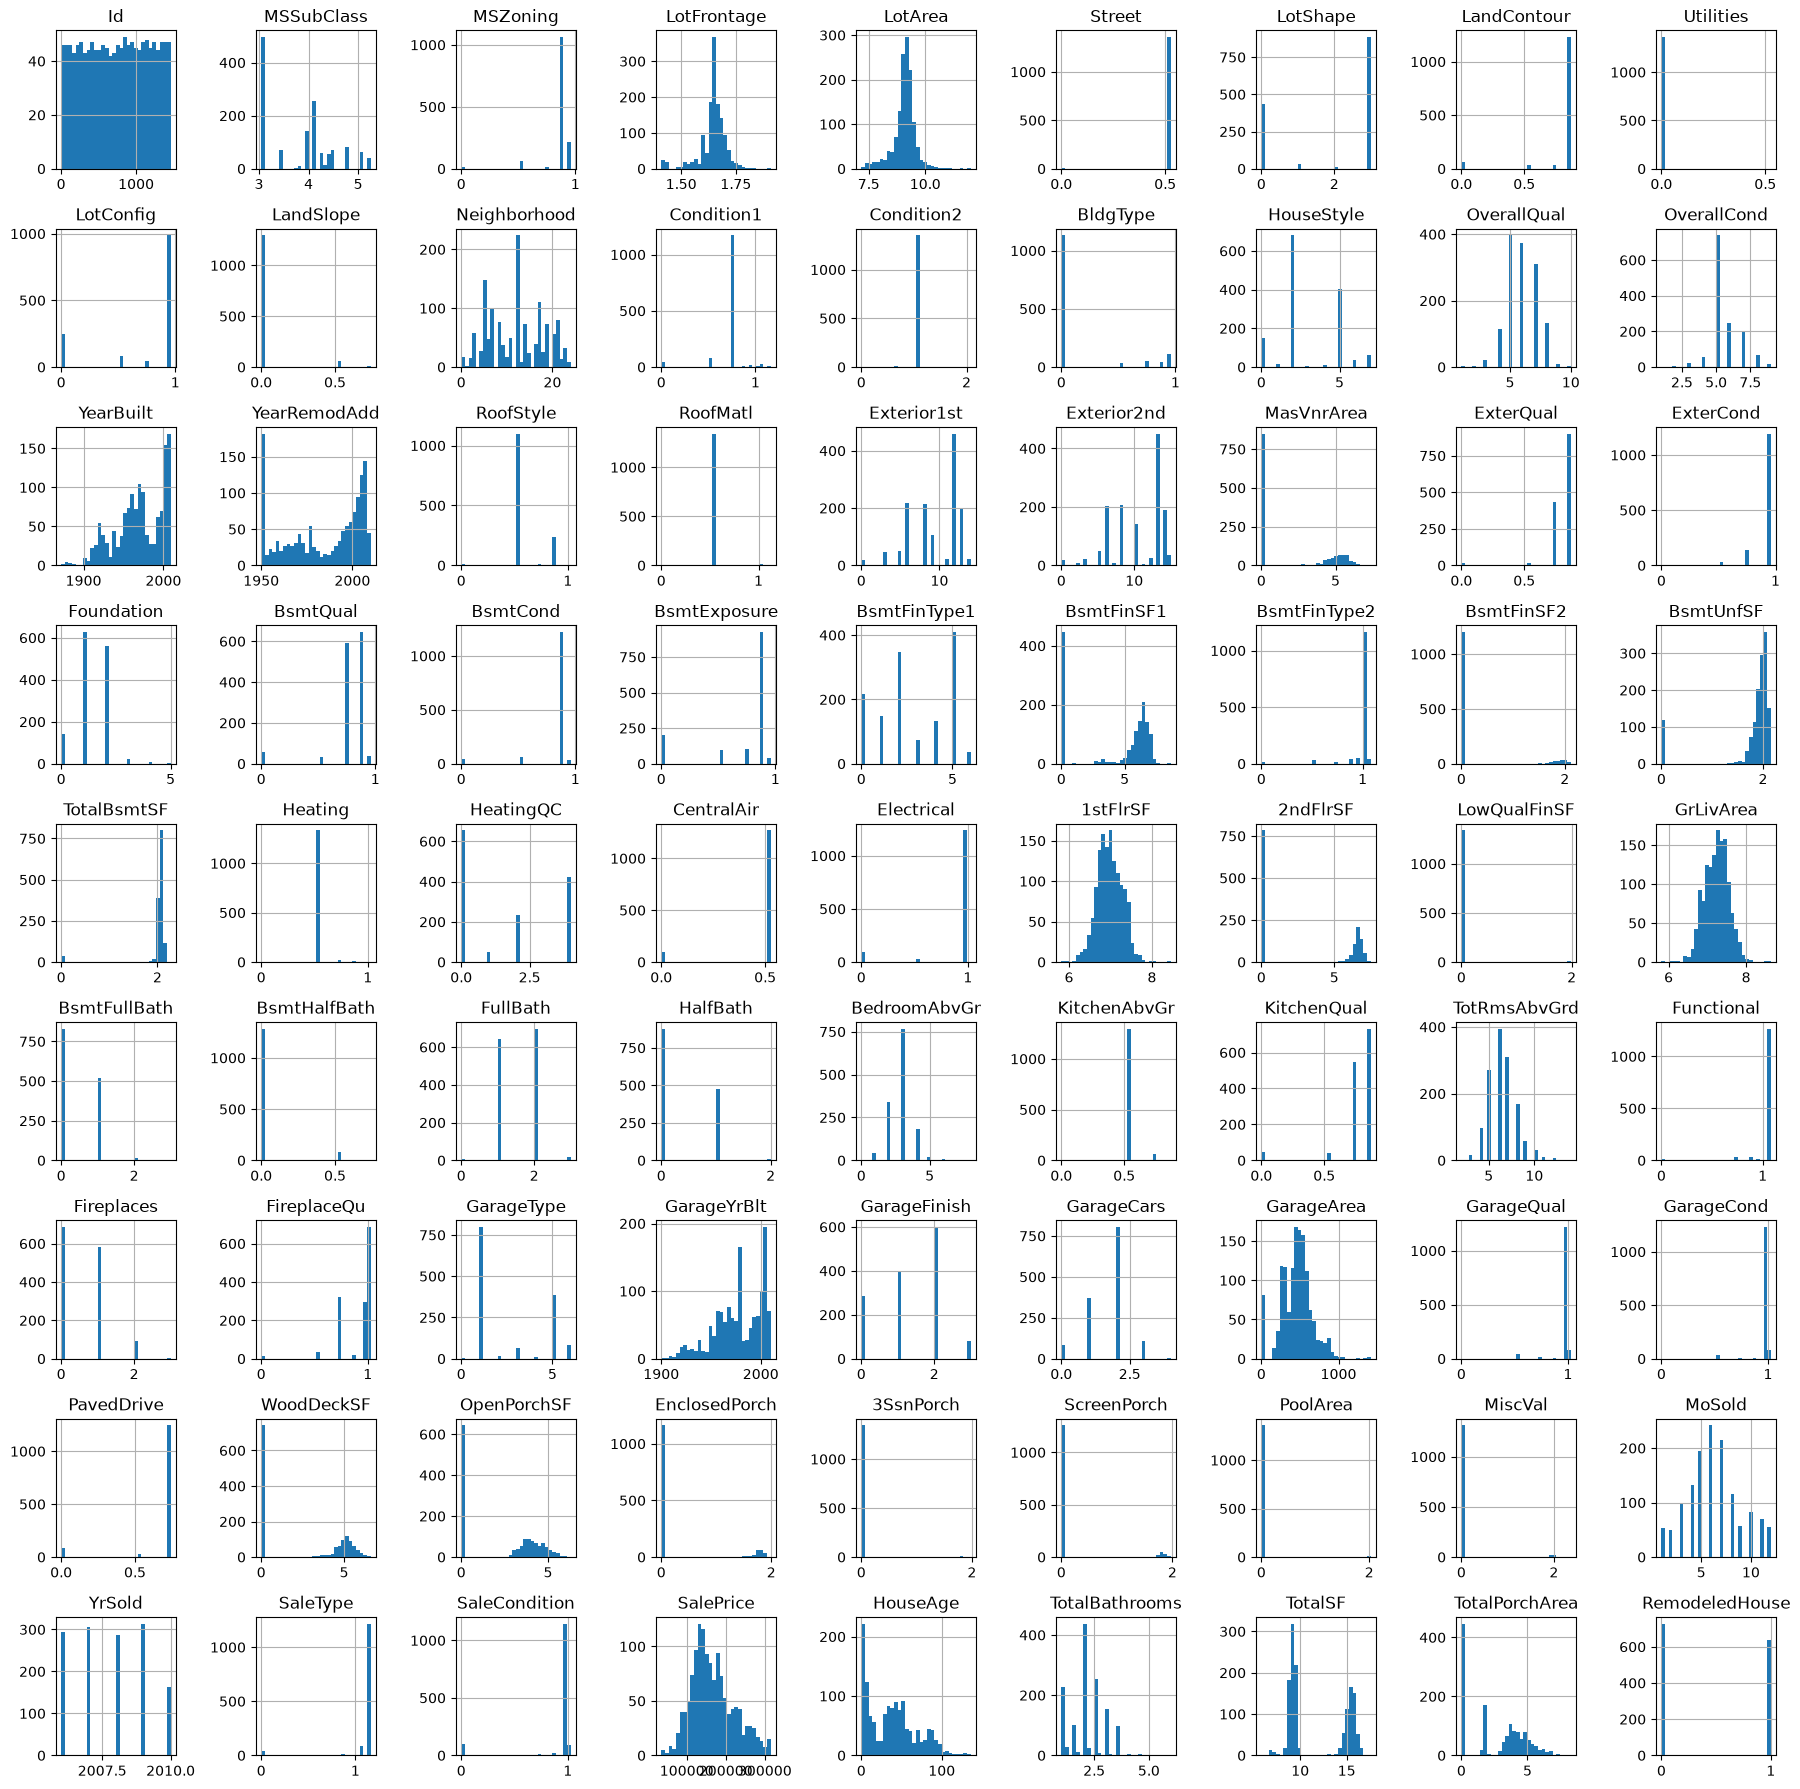

In [22]:
# Numerical Features Distribution
df.hist(figsize=(18,18),bins=30)
plt.tight_layout()
plt.show()

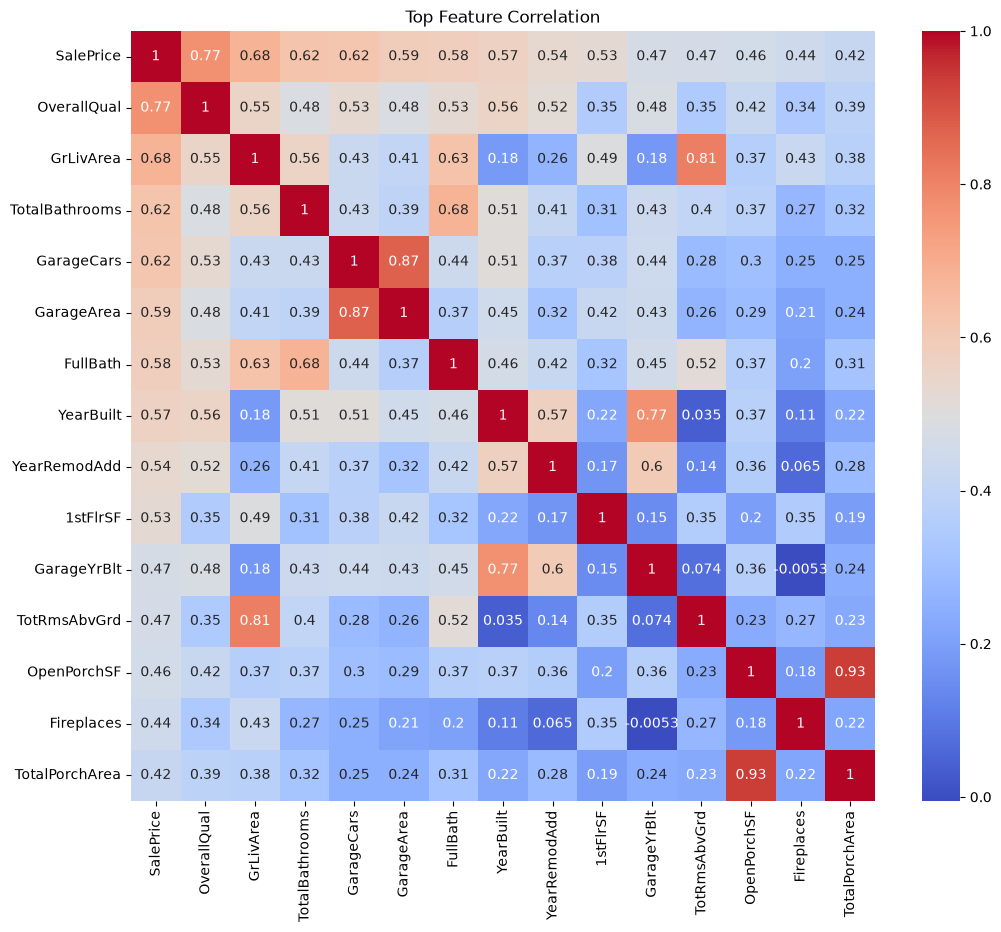

In [23]:
# Correlation of Top Features
top_features=corr.head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features].corr(),annot=True,cmap="coolwarm")
plt.title("Top Feature Correlation")
plt.show()

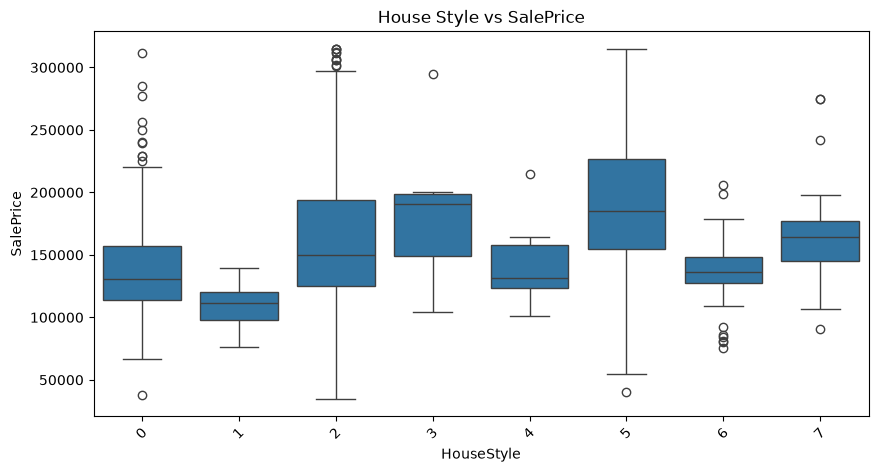

In [24]:
# SalePrice by House Style
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="HouseStyle",y="SalePrice")
plt.xticks(rotation=45)
plt.title("House Style vs SalePrice")
plt.show()